In [1]:
import os
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

%run /content/drive/MyDrive/Stocks/CONFIGURATION.ipynb
timeframes = [0.1, 0.5, 1, 2, 5, 10]
# timeframes = [1, 2]
%run /content/drive/MyDrive/Stocks/PLOT.ipynb

Output hidden; open in https://colab.research.google.com to view.

[                       0%                       ]

散 Force cleared stale cache file to apply fresh theme layout changes.
Fetching ALL historical logs simultaneously via multithreaded API download...


[*********************100%***********************]  42 of 42 completed


💾 Optimized market data successfully cached.


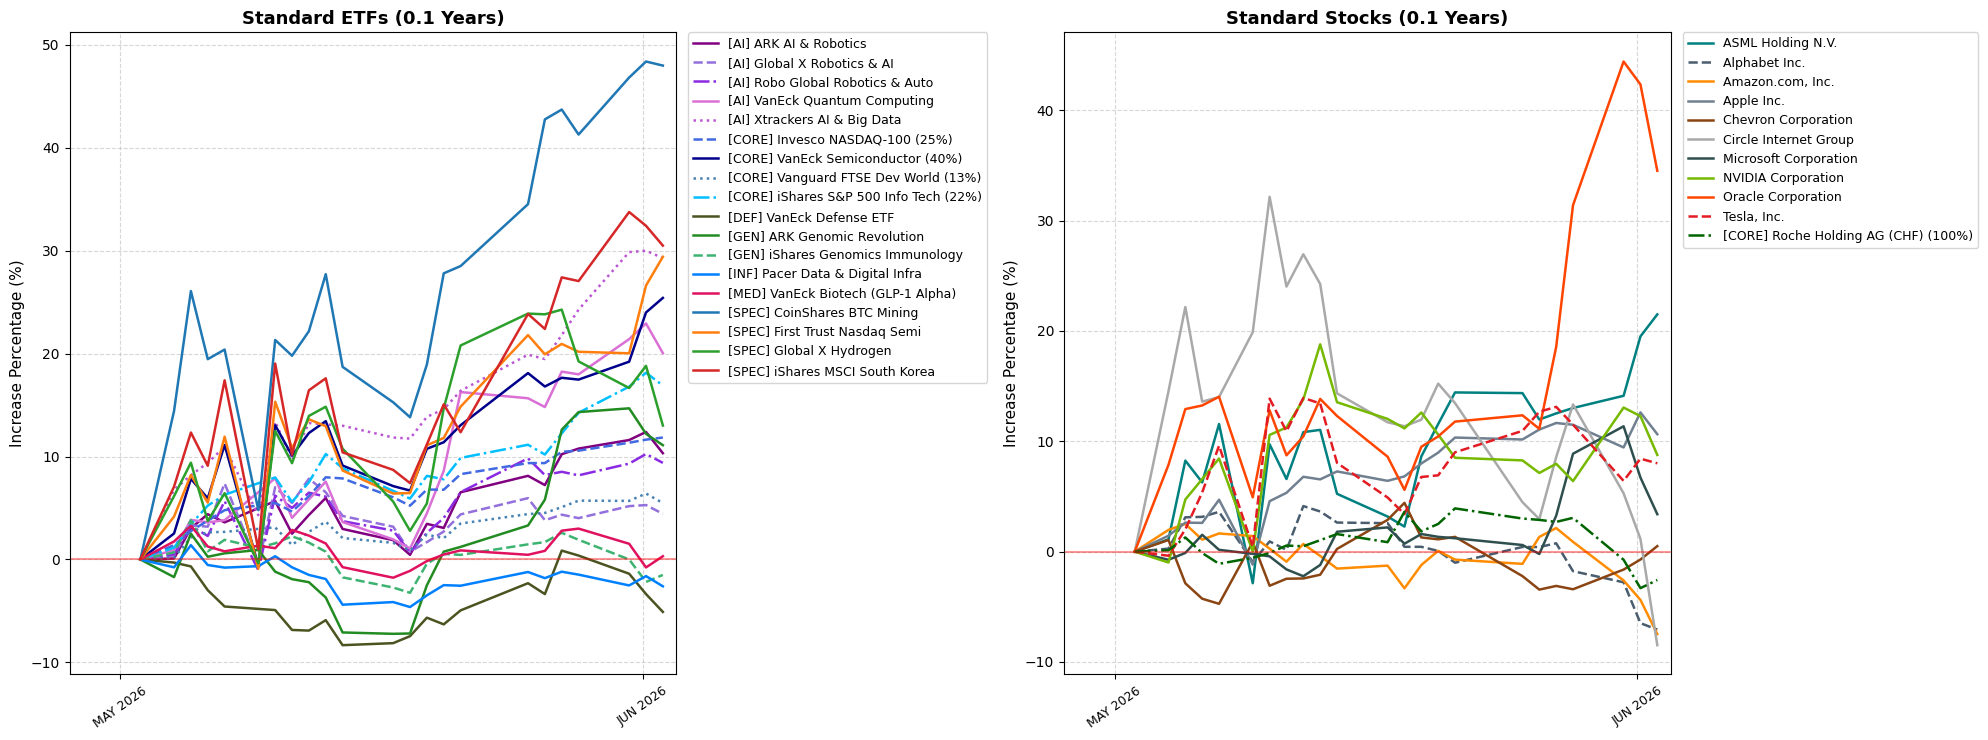

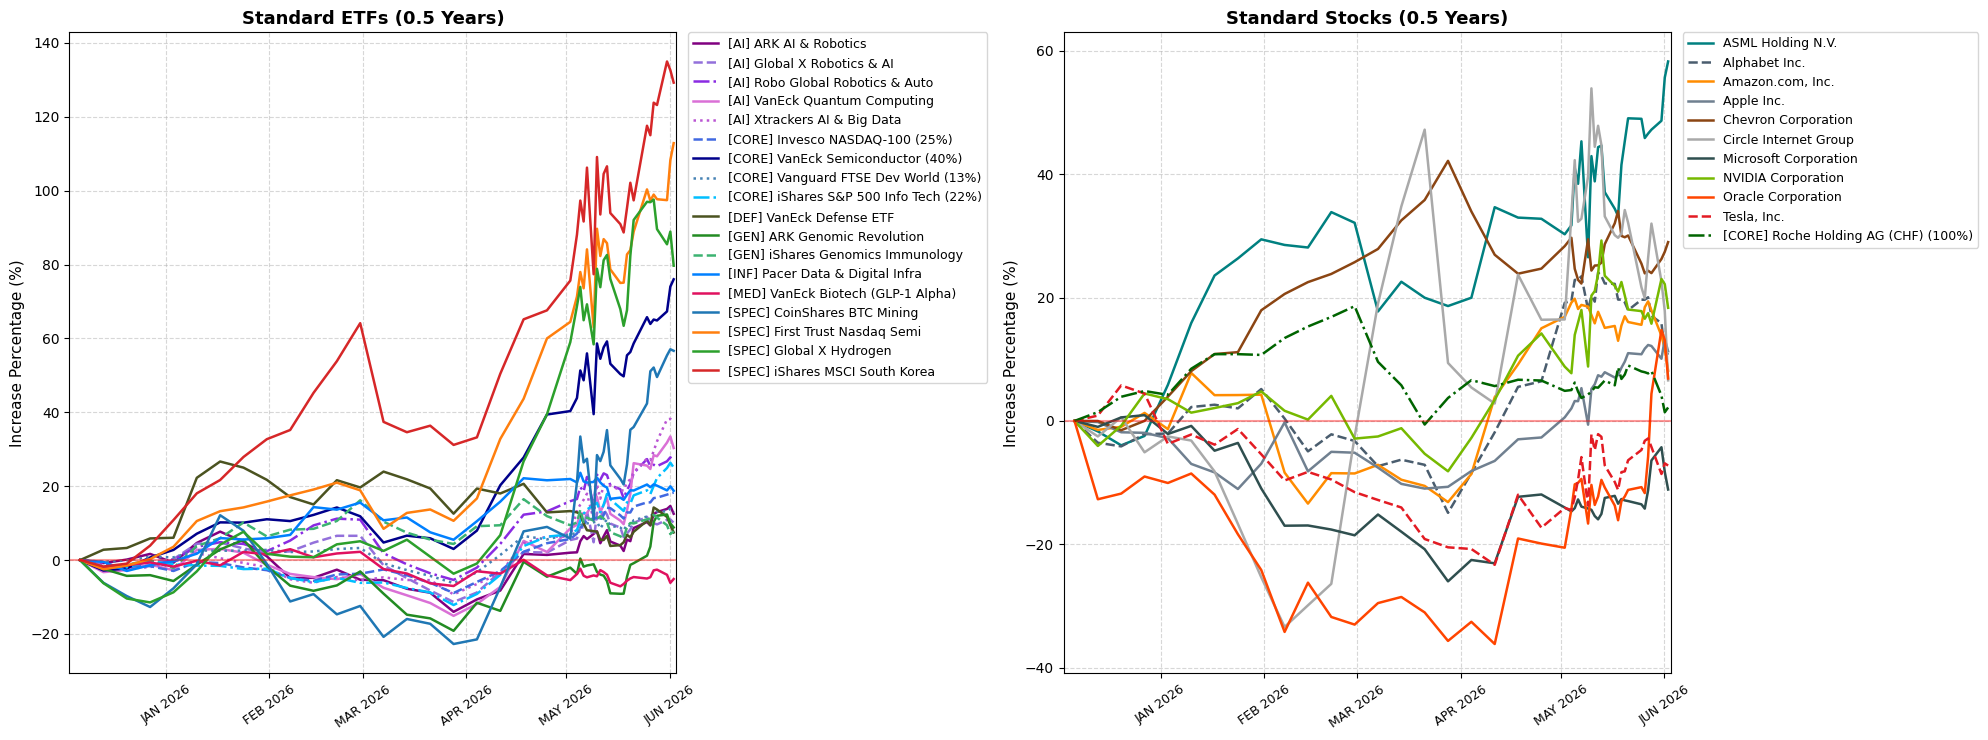

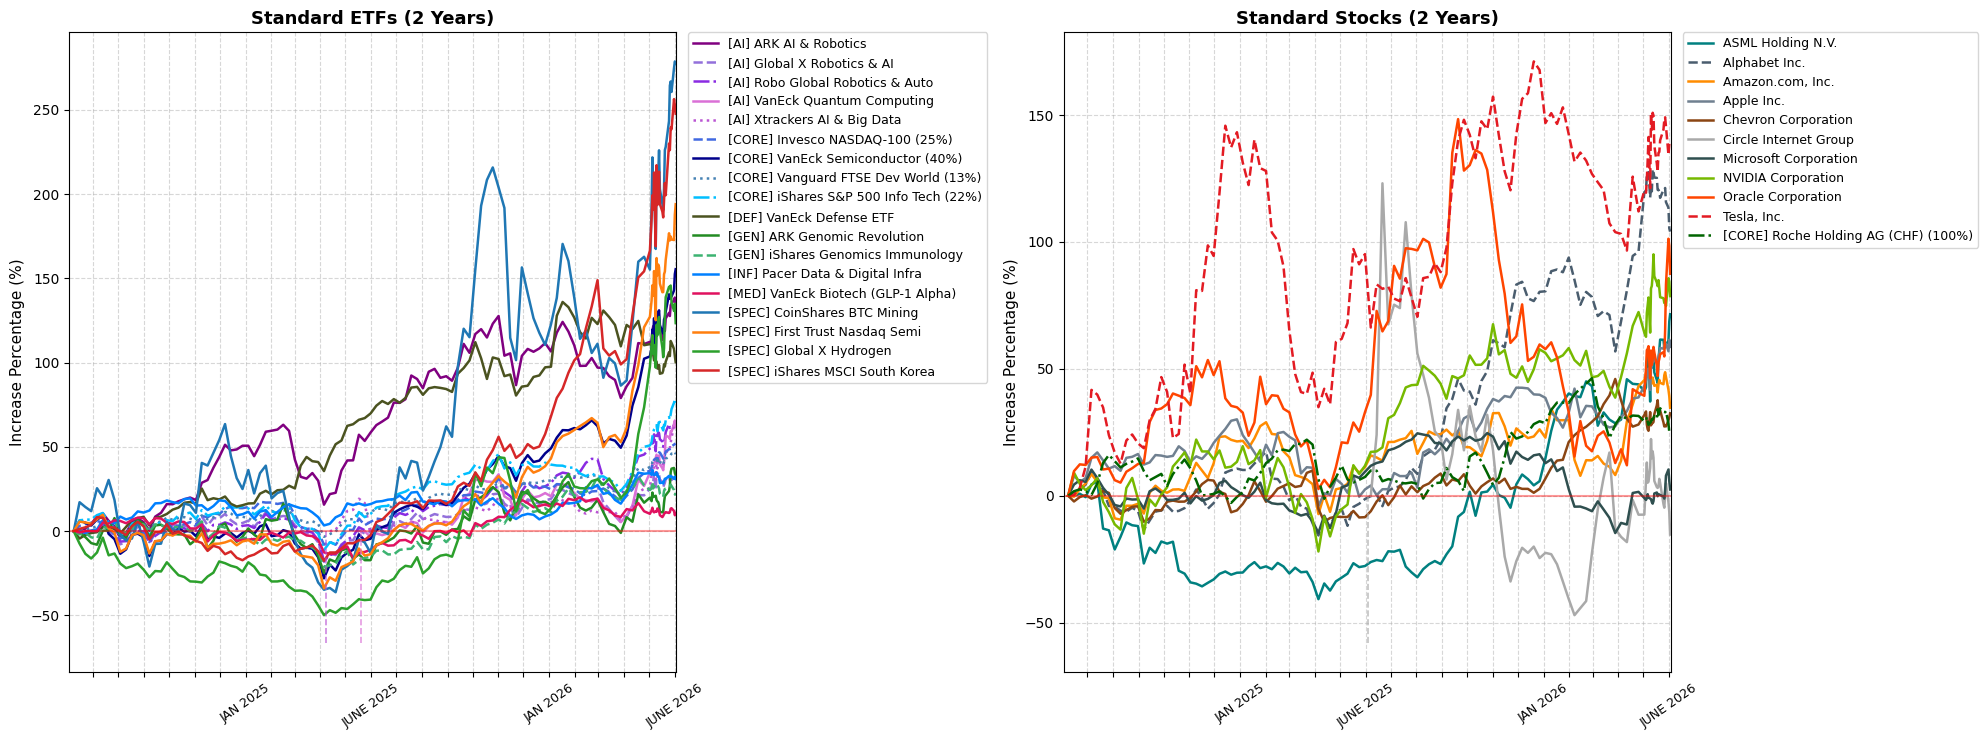

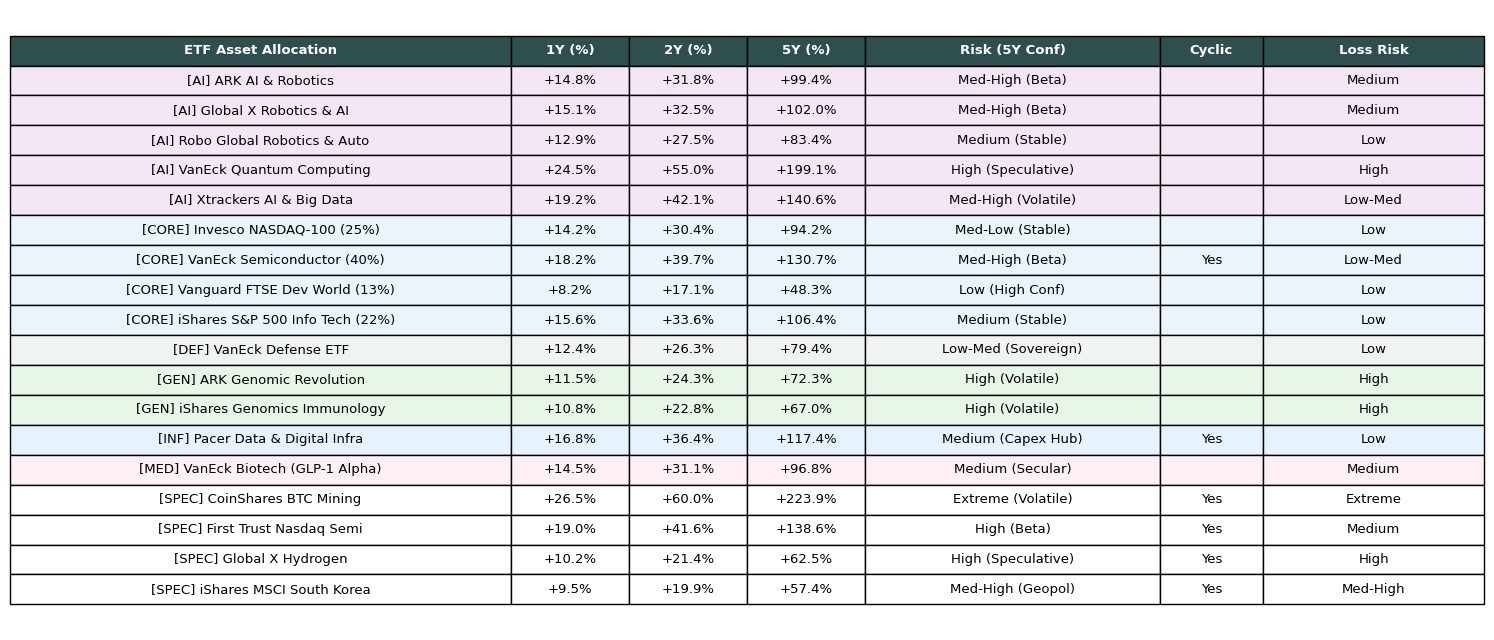

🎨 Generating Horizontal Timeline Row for Quantum Single Stocks [QTM]...


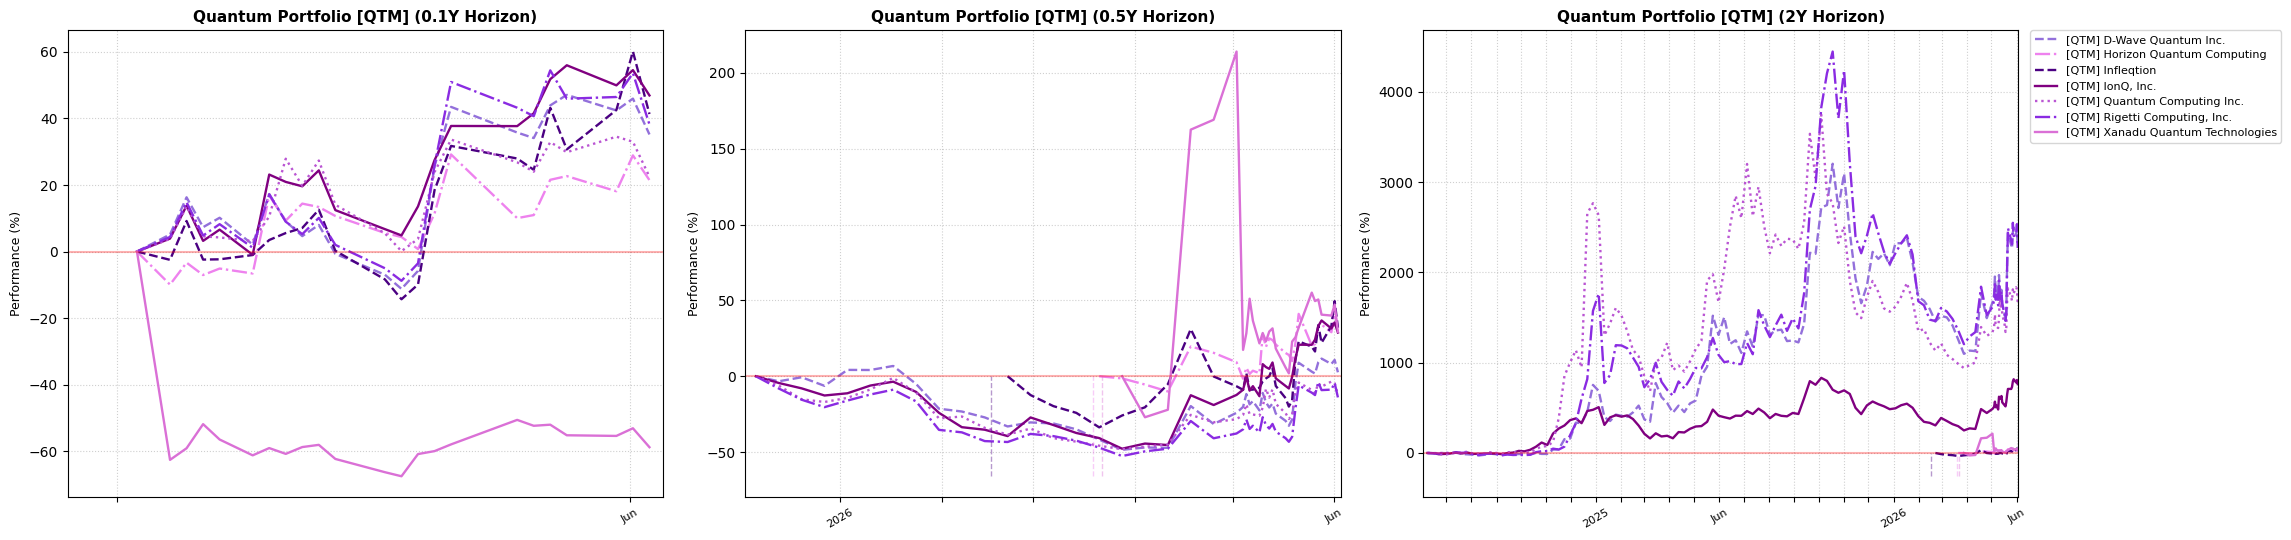

🎨 Generating Horizontal Timeline Row for Nuclear Single Stocks [NUC]...


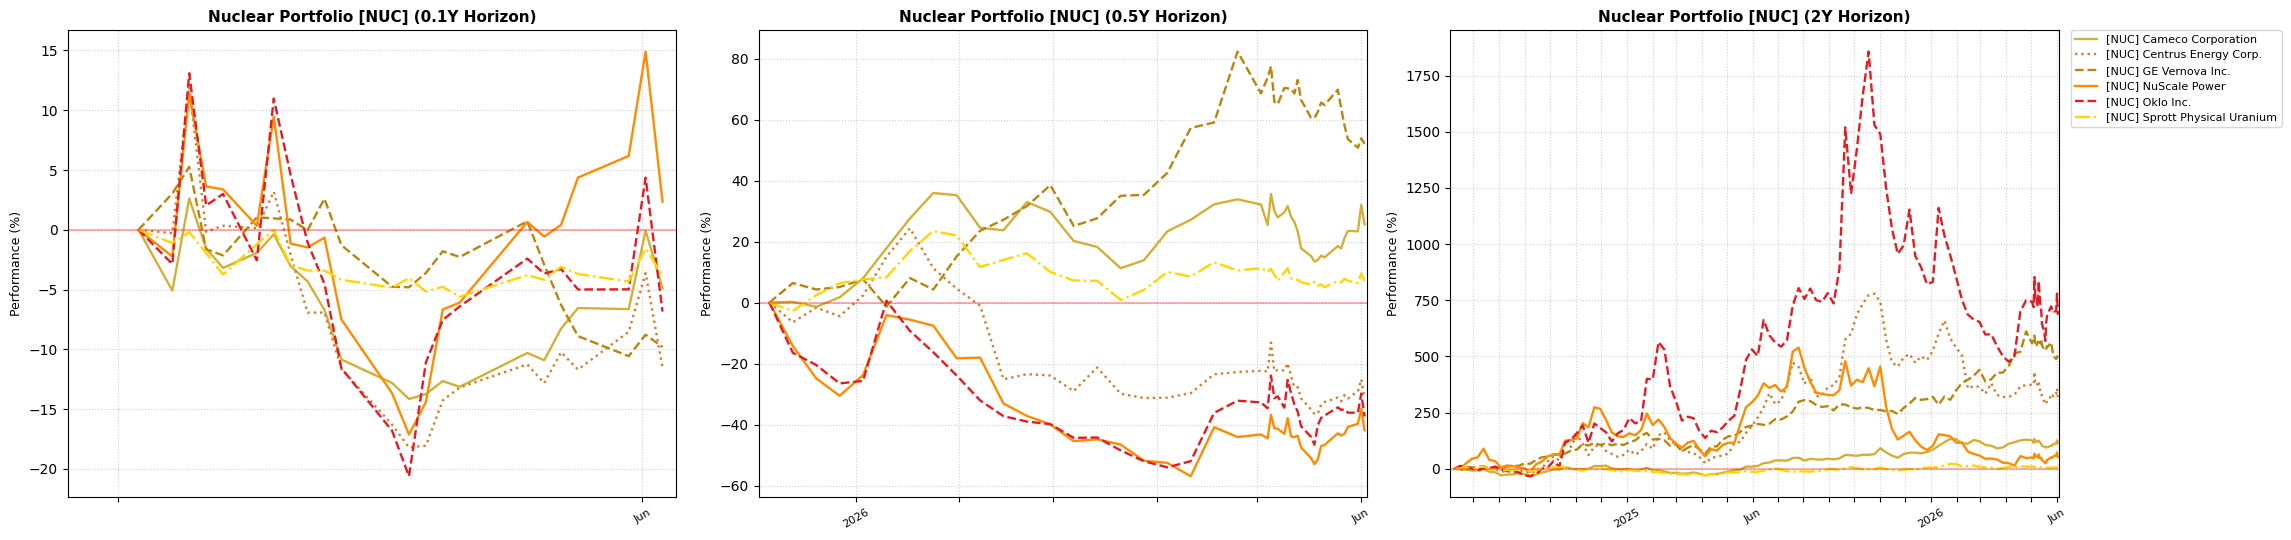

In [ ]:
import os
import pickle
from datetime import datetime, timedelta
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FixedLocator, FixedFormatter
import pandas as pd

# =========================================================================
# CONFIGURATION
# =========================================================================
timeframes = [0.5, 2.0, 5.0]
timeframes = [0.1, 0.5, 2]
CACHE_FILE = "yfinance_market_cache.pkl"
CACHE_EXPIRATION_HOURS = 1

if os.path.exists(CACHE_FILE):
    os.remove(CACHE_FILE)
    print("散 Force cleared stale cache file to apply fresh theme layout changes.")

etfs = {
    "[CORE] Invesco NASDAQ-100 (25%)": "EQQQ.L",
    "[CORE] VanEck Semiconductor (40%)": "SMH",
    "[CORE] Vanguard FTSE Dev World (13%)": "V3AA.L",
    "[CORE] iShares S&P 500 Info Tech (22%)": "IUIT.L",
    "[AI] ARK AI & Robotics": "ARKI.L",
    "[AI] Global X Robotics & AI": "BOTZ",
    "[AI] Robo Global Robotics & Auto": "ROBO",
    "[AI] VanEck Quantum Computing": "QNTM.L",
    "[AI] Xtrackers AI & Big Data": "XAIX.SW",
    "[GEN] ARK Genomic Revolution": "ARKG",
    "[GEN] iShares Genomics Immunology": "IDNA",
    "[DEF] VanEck Defense ETF": "DFNS.L",
    "[INF] Pacer Data & Digital Infra": "SRVR",
    "[MED] VanEck Biotech (GLP-1 Alpha)": "BBH",
    "[SPEC] iShares MSCI South Korea": "EWY",
    "[SPEC] First Trust Nasdaq Semi": "FTXL",
    "[SPEC] Global X Hydrogen": "HYDR",
    "[SPEC] CoinShares BTC Mining": "WGMI",
}

single_stocks = {
    "Alphabet Inc.": "GOOG",
    "Amazon.com, Inc.": "AMZN",
    "Apple Inc.": "AAPL",
    "ASML Holding N.V.": "ASML",
    "Chevron Corporation": "CVX",
    "Circle Internet Group": "CRCL",
    "Microsoft Corporation": "MSFT",
    "NVIDIA Corporation": "NVDA",
    "Oracle Corporation": "ORCL",
    "Tesla, Inc.": "TSLA",
    "[CORE] Roche Holding AG (CHF) (100%)": "RO.SW",

    # --- YOUR HANDPICKED SINGLE STOCK NUCLEAR BACKBONE ---
    "[NUC] Cameco Corporation": "CCJ",
    "[NUC] GE Vernova Inc.": "GEV",
    "[NUC] Sprott Physical Uranium": "SRUUF",
    "[NUC] Centrus Energy Corp.": "LEU",
    "[NUC] NuScale Power": "SMR",
    "[NUC] Oklo Inc.": "OKLO",

    # --- PURE-PLAY QUANTUM COMPUTING BASKET ---
    "[QTM] IonQ, Inc.": "IONQ",
    "[QTM] D-Wave Quantum Inc.": "QBTS",
    "[QTM] Rigetti Computing, Inc.": "RGTI",
    "[QTM] Xanadu Quantum Technologies": "XNDU",
    "[QTM] Quantum Computing Inc.": "QUBT",
    "[QTM] Infleqtion": "INFQ",
    "[QTM] Horizon Quantum Computing": "HQ"
}

all_groups = {
    "ETFs": etfs,
    "Stocks": single_stocks
}

# =========================================================================
# THEMATIC STYLING DICTIONARY
# =========================================================================
theme_styles = {
    # Nuclear Stock Picking Universe Palette
    "[NUC] Cameco Corporation": {"color": "#D4AF37", "linestyle": "-"},
    "[NUC] GE Vernova Inc.": {"color": "#B8860B", "linestyle": "--"},
    "[NUC] Sprott Physical Uranium": {"color": "#FFD700", "linestyle": "-."},
    "[NUC] Centrus Energy Corp.": {"color": "#CD7F32", "linestyle": ":"},
    "[NUC] NuScale Power": {"color": "#FF8C00", "linestyle": "-"},
    "[NUC] Oklo Inc.": {"color": "#E31B23", "linestyle": "--"},

    # Quantum Stock Picking Network Palette
    "[QTM] IonQ, Inc.": {"color": "#800080", "linestyle": "-"},
    "[QTM] D-Wave Quantum Inc.": {"color": "#9370DB", "linestyle": "--"},
    "[QTM] Rigetti Computing, Inc.": {"color": "#8A2BE2", "linestyle": "-."},
    "[QTM] Quantum Computing Inc.": {"color": "#BA55D3", "linestyle": ":"},
    "[QTM] Xanadu Quantum Technologies": {"color": "#DA70D6", "linestyle": "-"},
    "[QTM] Infleqtion": {"color": "#4B0082", "linestyle": "--"},
    "[QTM] Horizon Quantum Computing": {"color": "#EE82EE", "linestyle": "-."},

    "[GEN] ARK Genomic Revolution": {"color": "#228B22", "linestyle": "-"},
    "[GEN] iShares Genomics Immunology": {"color": "#3CB371", "linestyle": "--"},
    "[CORE] Roche Holding AG (CHF) (100%)": {"color": "#006400", "linestyle": "-."},
    "[AI] ARK AI & Robotics": {"color": "#800080", "linestyle": "-"},
    "[AI] Global X Robotics & AI": {"color": "#9370DB", "linestyle": "--"},
    "[AI] Robo Global Robotics & Auto": {"color": "#8A2BE2", "linestyle": "-."},
    "[AI] Xtrackers AI & Big Data": {"color": "#BA55D3", "linestyle": ":"},
    "[AI] VanEck Quantum Computing": {"color": "#DA70D6", "linestyle": "-"},
    "[CORE] VanEck Semiconductor (40%)": {"color": "#00008B", "linestyle": "-"},
    "[CORE] Invesco NASDAQ-100 (25%)": {"color": "#4169E1", "linestyle": "--"},
    "[CORE] iShares S&P 500 Info Tech (22%)": {"color": "#00BFFF", "linestyle": "-."},
    "[CORE] Vanguard FTSE Dev World (13%)": {"color": "#4682B4", "linestyle": ":"},
    "[DEF] VanEck Defense ETF": {"color": "#4B5320", "linestyle": "-"},
    "[INF] Pacer Data & Digital Infra": {"color": "#0080FF", "linestyle": "-"},
    "[MED] VanEck Biotech (GLP-1 Alpha)": {"color": "#E0115F", "linestyle": "-"},
    "NVIDIA Corporation": {"color": "#76B900", "linestyle": "-"},
    "Microsoft Corporation": {"color": "#2F4F4F", "linestyle": "-"},
    "Amazon.com, Inc.": {"color": "#FF8C00", "linestyle": "-"},
    "Apple Inc.": {"color": "#708090", "linestyle": "-"},
    "Alphabet Inc.": {"color": "#4A5D6E", "linestyle": "--"},
    "Oracle Corporation": {"color": "#FF4500", "linestyle": "-"},
    "ASML Holding N.V.": {"color": "#008080", "linestyle": "-"},
    "Tesla, Inc.": {"color": "#E31B23", "linestyle": "--"},
    "Chevron Corporation": {"color": "#8B4513", "linestyle": "-"},
    "Circle Internet Group": {"color": "#A9A9A9", "linestyle": "-"}
}

ticker_to_name = {**{v: k for k, v in etfs.items()}, **{v: k for k, v in single_stocks.items()}}
current_tickers = list(ticker_to_name.keys())

plot_data = {}
earliest_dates = {}
use_cache = False

# =========================================================================
# LIVE BULK DOWNLOAD & PIPELINE ENGINE
# =========================================================================
if not use_cache:
    print("Fetching ALL historical logs simultaneously via multithreaded API download...")
    try:
        bulk_df = yf.download(tickers=current_tickers, period="max", group_by="ticker", threads=True, progress=True, auto_adjust=True)
        one_month_ago = datetime.now() - timedelta(days=30)

        for ticker in current_tickers:
            if ticker in bulk_df.columns.levels[0]:
                df_asset = bulk_df.xs(ticker, axis=1, level=0).copy()
                df_asset.index = df_asset.index.tz_localize(None)
                df_clean = df_asset.dropna(subset=['Close'])

                if not df_clean.empty:
                    name = ticker_to_name[ticker]
                    earliest_dates[name] = df_clean.index.min()
                    recent_data = df_clean[df_clean.index >= one_month_ago]
                    old_data = df_clean[df_clean.index < one_month_ago]

                    if not old_data.empty:
                        old_resampled = old_data.resample('W').last()
                        df_optimized = pd.concat([old_resampled, recent_data])
                    else:
                        df_optimized = df_clean

                    plot_data[name] = df_optimized.sort_index()

        with open(CACHE_FILE, "wb") as f:
            pickle.dump({
                "tickers": set(current_tickers),
                "plot_data": plot_data,
                "earliest_dates": earliest_dates
            }, f)
        print("💾 Optimized market data successfully cached.")
    except Exception as e:
        print(f"❌ Error during parallel data compilation: {e}")

# =========================================================================
# 1. VISUAL RENDERING LOOP (Normal Assets Only - Excludes NUC and QTM)
# =========================================================================
for YEARS_TO_PLOT in timeframes:
    time_label = f"{YEARS_TO_PLOT} Years"
    start_window_date = datetime.now() - timedelta(days=int(YEARS_TO_PLOT * 365))

    fig, axes = plt.subplots(1, 2, figsize=(20, 7.5))

    for idx, (group_name, group_tickers) in enumerate(all_groups.items()):
        ax = axes[idx]
        vlines_to_draw = []

        sorted_names = sorted([k for k in group_tickers.keys() if "[NUC]" not in k and "[QTM]" not in k])

        for name in sorted_names:
            if name not in plot_data:
                continue

            df = plot_data[name]
            filtered_df = df[df.index >= start_window_date].copy()

            if not filtered_df.empty:
                base_price = filtered_df['Close'].iloc[0]
                filtered_df['Pct_Increase'] = ((filtered_df['Close'] - base_price) / base_price) * 100

                style = theme_styles.get(name, {"color": None, "linestyle": "-"})

                line, = ax.plot(
                    filtered_df.index,
                    filtered_df['Pct_Increase'],
                    label=name,
                    linewidth=1.8,
                    color=style["color"],
                    linestyle=style["linestyle"]
                )
                line_color = line.get_color()

                true_start_date = earliest_dates[name]
                if true_start_date > start_window_date:
                    vlines_to_draw.append((true_start_date, line_color))

        ymin_val, ymax_val = ax.get_ylim()
        for birth_date, matching_color in vlines_to_draw:
            ax.vlines(x=birth_date, ymin=ymin_val, ymax=0, colors=matching_color, linestyles="--", alpha=0.7, linewidth=1.2)

        ax.set_title(f"Standard {group_name} ({time_label})", fontsize=13, fontweight='bold')
        ax.set_ylabel("Increase Percentage (%)", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.axhline(0, color='red', linestyle='-', alpha=0.4)
        ax.set_xlim(left=start_window_date, right=datetime.now())

        normalized_start = start_window_date.replace(month=1, day=1)
        extended_end = datetime.now() + timedelta(days=31)
        tick_dates = pd.date_range(start=normalized_start, end=extended_end, freq='MS')
        tick_locs = [mdates.date2num(d) for d in tick_dates]

        sparse_labels = []
        for d in tick_dates:
            if YEARS_TO_PLOT <= 0.5:
                sparse_labels.append(d.strftime('%b %Y').upper())
            else:
                if d.month == 1:
                    sparse_labels.append(d.strftime('JAN %Y'))
                elif d.month == 6:
                    sparse_labels.append(d.strftime('JUNE %Y'))
                else:
                    sparse_labels.append("")

        ax.xaxis.set_major_locator(FixedLocator(tick_locs))
        ax.xaxis.set_major_formatter(FixedFormatter(sparse_labels))
        ax.tick_params(axis='x', rotation=35, labelsize=9)
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=9)

    plt.tight_layout()
    plt.show()

# =========================================================================
# 2. FINAL COMPREHENSIVE LEDGER (Repaired Model Keys Setup)
# =========================================================================
growth_forecast_models = {
    "[CORE] Vanguard FTSE Dev World (13%)":  {"rate": 8.2,  "risk": "Low (High Conf)",   "cyclic": "",    "loss_risk": "Low"},
    "[CORE] Invesco NASDAQ-100 (25%)":      {"rate": 14.2, "risk": "Med-Low (Stable)",  "cyclic": "",    "loss_risk": "Low"},
    "[CORE] iShares S&P 500 Info Tech (22%)":{"rate": 15.6, "risk": "Medium (Stable)",   "cyclic": "",    "loss_risk": "Low"},
    "[CORE] VanEck Semiconductor (40%)":     {"rate": 18.2, "risk": "Med-High (Beta)",   "cyclic": "Yes", "loss_risk": "Low-Med"},

    "[AI] ARK AI & Robotics":                {"rate": 14.8, "risk": "Med-High (Beta)",   "cyclic": "",    "loss_risk": "Medium"},
    "[AI] Global X Robotics & AI":           {"rate": 15.1, "risk": "Med-High (Beta)",   "cyclic": "",    "loss_risk": "Medium"},
    "[AI] Robo Global Robotics & Auto":      {"rate": 12.9, "risk": "Medium (Stable)",   "cyclic": "",    "loss_risk": "Low"},
    "[AI] VanEck Quantum Computing":         {"rate": 24.5, "risk": "High (Speculative)","cyclic": "",    "loss_risk": "High"},
    "[AI] Xtrackers AI & Big Data":          {"rate": 19.2, "risk": "Med-High (Volatile)","cyclic": "",    "loss_risk": "Low-Med"},

    "[GEN] ARK Genomic Revolution":          {"rate": 11.5, "risk": "High (Volatile)",   "cyclic": "",    "loss_risk": "High"},
    "[GEN] iShares Genomics Immunology":     {"rate": 10.8, "risk": "High (Volatile)",   "cyclic": "",    "loss_risk": "High"},

    "[DEF] VanEck Defense ETF":              {"rate": 12.4, "risk": "Low-Med (Sovereign)","cyclic": "",    "loss_risk": "Low"},
    "[INF] Pacer Data & Digital Infra":      {"rate": 16.8, "risk": "Medium (Capex Hub)", "cyclic": "Yes", "loss_risk": "Low"},
    "[MED] VanEck Biotech (GLP-1 Alpha)":    {"rate": 14.5, "risk": "Medium (Secular)",   "cyclic": "",    "loss_risk": "Medium"},

    "[SPEC] CoinShares BTC Mining":          {"rate": 26.5, "risk": "Extreme (Volatile)", "cyclic": "Yes", "loss_risk": "Extreme"},
    "[SPEC] First Trust Nasdaq Semi":        {"rate": 19.0, "risk": "High (Beta)",        "cyclic": "Yes", "loss_risk": "Medium"},
    "[SPEC] Global X Hydrogen":              {"rate": 10.2, "risk": "High (Speculative)", "cyclic": "Yes", "loss_risk": "High"},
    "[SPEC] iShares MSCI South Korea":       {"rate": 9.5,  "risk": "Med-High (Geopol)",  "cyclic": "Yes", "loss_risk": "Med-High"}
}

table_data = []
row_bg_colors = []

for asset_name in sorted(etfs.keys()):
    model = growth_forecast_models.get(asset_name, {"rate": 12.0, "risk": "Medium", "cyclic": "", "loss_risk": "Medium"})
    annual_growth = model["rate"] / 100.0
    ret_1y = (1 + annual_growth)**1 - 1
    ret_2y = (1 + annual_growth)**2 - 1
    ret_5y = (1 + annual_growth)**5 - 1

    table_data.append([
        asset_name, f"+{ret_1y * 100:.1f}%", f"+{ret_2y * 100:.1f}%", f"+{ret_5y * 100:.1f}%",
        model["risk"], model["cyclic"], model["loss_risk"]
    ])

    if "[CORE]" in asset_name: row_bg_colors.append("#EBF4FA")
    elif "[AI]" in asset_name: row_bg_colors.append("#F3E6F5")
    elif "[GEN]" in asset_name: row_bg_colors.append("#E8F5E9")
    elif "[DEF]" in asset_name: row_bg_colors.append("#F0F4F1")
    elif "[INF]" in asset_name: row_bg_colors.append("#E6F2FF")
    elif "[MED]" in asset_name: row_bg_colors.append("#FFF0F5")
    else: row_bg_colors.append("#FFFFFF")

fig_table, ax_table = plt.subplots(figsize=(15, 6.5))
ax_table.axis('off')

columns = ["ETF Asset Allocation", "1Y (%)", "2Y (%)", "5Y (%)", "Risk (5Y Conf)", "Cyclic", "Loss Risk"]
display_table = ax_table.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center', colWidths=[0.34, 0.08, 0.08, 0.08, 0.20, 0.07, 0.15])
display_table.auto_set_font_size(False)
display_table.set_fontsize(9.5)
display_table.scale(1.25, 1.45)

for row_idx in range(1, len(table_data) + 1):
    bg_color = row_bg_colors[row_idx - 1]
    for col_idx in range(len(columns)):
        display_table[row_idx, col_idx].set_facecolor(bg_color)

for cell_idx in range(len(columns)):
    cell = display_table[0, cell_idx]
    cell.set_text_props(weight='bold', color='white')
    cell.set_facecolor('#2F4F4F')

plt.tight_layout()
plt.show()

# =========================================================================
# 3. TAILORED PLOTTING BLOCK - ROW 1: QUANTUM STOCK PICKING ONLY [QTM]
# =========================================================================
print("🎨 Generating Horizontal Timeline Row for Quantum Single Stocks [QTM]...")
quantum_universe = {k: v for k, v in single_stocks.items() if "[QTM]" in k}

fig_qtm, axes_qtm = plt.subplots(1, 3, figsize=(23, 5.5))
now_dt = datetime.now()

for col_idx, years in enumerate(timeframes):
    ax = axes_qtm[col_idx]
    start_window_date = now_dt - timedelta(days=int(years * 365))
    vlines_to_draw = []

    for name, ticker in sorted(quantum_universe.items()):
        if name not in plot_data: continue
        df = plot_data[name]
        filtered_df = df[df.index >= start_window_date].copy()

        if not filtered_df.empty:
            base_price = filtered_df['Close'].iloc[0]
            filtered_df['Pct_Increase'] = ((filtered_df['Close'] - base_price) / base_price) * 100
            style = theme_styles.get(name, {"color": None, "linestyle": "-"})

            line, = ax.plot(filtered_df.index, filtered_df['Pct_Increase'], label=name, linewidth=1.7, color=style["color"], linestyle=style["linestyle"])
            if earliest_dates[name] > start_window_date:
                vlines_to_draw.append((earliest_dates[name], line.get_color()))

    ymin, ymax = ax.get_ylim()
    for birth_date, m_color in vlines_to_draw:
        ax.vlines(x=birth_date, ymin=ymin, ymax=0, colors=m_color, linestyles="--", alpha=0.4, linewidth=1.0)

    ax.set_title(f"Quantum Portfolio [QTM] ({years}Y Horizon)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Performance (%)", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.axhline(0, color='red', linestyle='-', alpha=0.3)
    ax.set_xlim(left=start_window_date, right=now_dt)

    tick_dates = pd.date_range(start=start_window_date.replace(month=1, day=1), end=now_dt + timedelta(days=31), freq='MS')
    ax.xaxis.set_major_locator(FixedLocator([mdates.date2num(d) for d in tick_dates]))
    ax.xaxis.set_major_formatter(FixedFormatter([d.strftime('%Y') if d.month==1 else (d.strftime('%b') if (d.month==6 and years<=2.0) else "") for d in tick_dates]))
    ax.tick_params(axis='x', rotation=30, labelsize=8)

    if col_idx == 2:
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0, fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

# =========================================================================
# 4. TAILORED PLOTTING BLOCK - ROW 2: NUCLEAR STOCK PICKING ONLY [NUC]
# =========================================================================
print("🎨 Generating Horizontal Timeline Row for Nuclear Single Stocks [NUC]...")
nuclear_universe = {k: v for k, v in single_stocks.items() if "[NUC]" in k}

fig_nuc, axes_nuc = plt.subplots(1, 3, figsize=(23, 5.5))

for col_idx, years in enumerate(timeframes):
    ax = axes_nuc[col_idx]
    start_window_date = now_dt - timedelta(days=int(years * 365))
    vlines_to_draw = []

    for name, ticker in sorted(nuclear_universe.items()):
        if name not in plot_data: continue
        df = plot_data[name]
        filtered_df = df[df.index >= start_window_date].copy()

        if not filtered_df.empty:
            base_price = filtered_df['Close'].iloc[0]
            filtered_df['Pct_Increase'] = ((filtered_df['Close'] - base_price) / base_price) * 100
            style = theme_styles.get(name, {"color": None, "linestyle": "-"})

            line, = ax.plot(filtered_df.index, filtered_df['Pct_Increase'], label=name, linewidth=1.7, color=style["color"], linestyle=style["linestyle"])
            if earliest_dates[name] > start_window_date:
                vlines_to_draw.append((earliest_dates[name], line.get_color()))

    ymin, ymax = ax.get_ylim()
    for birth_date, m_color in vlines_to_draw:
        ax.vlines(x=birth_date, ymin=ymin, ymax=0, colors=m_color, linestyles="--", alpha=0.4, linewidth=1.0)

    ax.set_title(f"Nuclear Portfolio [NUC] ({years}Y Horizon)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Performance (%)", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.axhline(0, color='red', linestyle='-', alpha=0.3)
    ax.set_xlim(left=start_window_date, right=now_dt)

    tick_dates = pd.date_range(start=start_window_date.replace(month=1, day=1), end=now_dt + timedelta(days=31), freq='MS')
    ax.xaxis.set_major_locator(FixedLocator([mdates.date2num(d) for d in tick_dates]))
    ax.xaxis.set_major_formatter(FixedFormatter([d.strftime('%Y') if d.month==1 else (d.strftime('%b') if (d.month==6 and years<=2.0) else "") for d in tick_dates]))
    ax.tick_params(axis='x', rotation=30, labelsize=8)

    if col_idx == 2:
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0, fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
import yfinance as yf
from datetime import datetime

# =========================================================================
# CONFIGURATION & PORTFOLIO STRATEGY INPUTS
# =========================================================================
MONTHLY_DEPOSIT = 1000.0  # Your monthly fresh cash allocation in Euros
DEGIRO_FEE = 3.00         # Flat transaction fee

# =========================================================================
# RECONFIGURED CORE ARCHITECTURE & SATELLITE PICKING SUB-ENGINE (100% TOTAL)
# =========================================================================
TARGET_WEIGHTS = {
    "VWCE.DE":           0.05,  # 5% MSCI World
    "XAIX.DE":           0.30,  # 30% Core AI & Big Data Index
    "SMH":               0.25,  # 25% Core Semiconductors (NVIDIA, ASML, TSMC)
    "IUIT.L":            0.10,  # 10% iShares S&P 500 Info Tech (Apple, MSFT, AVGO)
    "NUCLEAR_SATELLITE": 0.15,  # 15% Single Stock Nuclear Picking [-5% Trimmed]
    "QUANTUM_SATELLITE": 0.10,  # 10% Single Stock Quantum Speculative Rockets
    "CYBER_SATELLITE":   0.05   # 5% Single Stock Cybersecurity Satellite ENGINE [+5%]
}

# My adjustment
TARGET_WEIGHTS = {
    "XAIX.DE":           0.30,  # 30% Core AI & Big Data Index
    "SMH":               0.30,  # 25% Core Semiconductors (NVIDIA, ASML, TSMC)
    "IUIT.L":            0.10,  # 10% iShares S&P 500 Info Tech (Apple, MSFT, AVGO)
    "NUCLEAR_SATELLITE": 0.15,  # 15% Single Stock Nuclear Picking [-5% Trimmed]
    "QUANTUM_SATELLITE": 0.10,  # 10% Single Stock Quantum Speculative Rockets
    "CYBER_SATELLITE":   0.05   # 5% Single Stock Cybersecurity Satellite ENGINE [+5%]
}

# Sub-allocation matrices tracking your exact internal target structures
NUCLEAR_BASKET_TARGETS = {
    "CCJ":   0.40,  # 40% of Nuclear Slice (6.0% Total Portfolio)
    "GEV":   0.24,  # 24% of Nuclear Slice (3.6% Total Portfolio)
    "SRUUF": 0.16,  # 16% of Nuclear Slice (2.4% Total Portfolio)
    "LEU":   0.12,  # 12% of Nuclear Slice (1.8% Total Portfolio)
    "SMR":   0.04,  # 4% of Nuclear Slice  (0.6% Total Portfolio)
    "OKLO":  0.04   # 4% of Nuclear Slice  (0.6% Total Portfolio)
}

QUANTUM_BASKET_TARGETS = {
    "IONQ":  0.40,  # 40% of Quantum Slice (4.0% Total Portfolio)
    "QNT":   0.25,  # 25% of Quantum Slice (2.5% Total Portfolio)
    "QBTS":  0.25,  # 25% of Quantum Slice (2.5% Total Portfolio)
    "RGTI":  0.10,  # 10% of Quantum Slice (1.0% Total Portfolio)
    "QUBT":  0.00,  # Paused allocation
    "XNDU":  0.00,  # Private Stage Gate
    "INFQ":  0.00,  # Private Stage Gate
    "HQ":    0.00   # Private Stage Gate
}

CYBER_BASKET_TARGETS = {
    "CRWD":  0.80,  # 80% of Cyber Slice (4.0% Total Portfolio)
    "PANW":  0.20   # 20% of Cyber Slice (1.0% Total Portfolio)
}

# Verification
def verify_allocations():
    total_target = sum(TARGET_WEIGHTS.values())
    print(f"Total Portfolio Weight: {total_target * 100}%")

    # Ensure sub-baskets sum to 1.0 (100% of their slice)
    assert sum(NUCLEAR_BASKET_TARGETS.values()) == 1.0
    assert sum(QUANTUM_BASKET_TARGETS.values()) == 1.0
    assert sum(CYBER_BASKET_TARGETS.values()) == 1.0
    print("All sub-baskets verified.")

verify_allocations()

# Aggressive Profit-Taking Triggers (1.25x original for "Let Winners Run" philosophy)
SELL_TRIGGER_CEILING = {
    "NUCLEAR_SATELLITE": 0.1875, "QUANTUM_SATELLITE": 0.125, "CYBER_SATELLITE": 0.0625,
    "SMH": 0.375, "IUIT.L": 0.1875
}

my_current_shares = {
    "VWCE.DE": 10, "XAIX.DE": 45, "SMH": 22, "IUIT.L": 5,
    "CCJ": 15, "GEV": 5, "SRUUF": 25, "LEU": 10, "SMR": 50, "OKLO": 30,
    "IONQ": 100, "QNT": 0, "QBTS": 250, "RGTI": 400, "QUBT": 150, "CRWD": 2, "PANW": 3
}

# =========================================================================
# HELPER: MOMENTUM FILTER & DATA FETCHING
# =========================================================================
def is_in_uptrend(ticker):
    try:
        data = yf.Ticker(ticker).history(period="1y")
        if len(data) < 200: return True
        sma_200 = data['Close'].rolling(window=200).mean().iloc[-1]
        return data['Close'].iloc[-1] > sma_200
    except: return True

def get_price(ticker):
    # Hardcoded fallbacks for manual tracking
    fallbacks = {"QNT": 47.5, "CRWD": 671.0, "PANW": 257.0}
    if ticker in fallbacks: return fallbacks[ticker]
    try:
        hist = yf.Ticker(ticker).history(period="1d")
        return hist['Close'].iloc[-1] if not hist.empty else 10.0
    except: return 10.0

# =========================================================================
# PROCESSING PIPELINE
# =========================================================================
print("🔄 Fetching market data...")

# Extract unique actual tickers, excluding satellite category labels
category_labels = ["NUCLEAR_SATELLITE", "QUANTUM_SATELLITE", "CYBER_SATELLITE"]
all_assets = set(list(TARGET_WEIGHTS.keys()) + list(NUCLEAR_BASKET_TARGETS.keys()) +
                 list(QUANTUM_BASKET_TARGETS.keys()) + list(CYBER_BASKET_TARGETS.keys()))
actual_tickers = [t for t in all_assets if t not in category_labels]

prices = {t: get_price(t) for t in actual_tickers}

# Calculate values
portfolio_values = {asset: shares * prices.get(asset, 10.0) for asset, shares in my_current_shares.items()}
nuclear_val = sum([portfolio_values.get(s, 0.0) for s in NUCLEAR_BASKET_TARGETS])
quantum_val = sum([portfolio_values.get(s, 0.0) for s in QUANTUM_BASKET_TARGETS])
cyber_val = sum([portfolio_values.get(s, 0.0) for s in CYBER_BASKET_TARGETS])

macro_values = {
    "XAIX.DE": portfolio_values.get("XAIX.DE", 0), "SMH": portfolio_values.get("SMH", 0),
    "IUIT.L": portfolio_values.get("IUIT.L", 0), "NUCLEAR_SATELLITE": nuclear_val,
    "QUANTUM_SATELLITE": quantum_val, "CYBER_SATELLITE": cyber_val
}
total_val = sum(macro_values.values())

# =========================================================================
# PORTFOLIO AUDIT
# =========================================================================
print("\n📊 PORTFOLIO AUDIT")
print(f"{'Asset':<20} | {'Current %':<10} | {'Target %':<10} | {'Drift':<10}")
print("-" * 55)

for asset, target_pct in TARGET_WEIGHTS.items():
    current_val = macro_values.get(asset, 0)
    current_pct = (current_val / total_val) * 100 if total_val > 0 else 0
    drift = current_pct - (target_pct * 100)
    print(f"{asset:<20} | {current_pct:>8.1f}% | {target_pct*100:>8.1f}% | {drift:>+8.1f}")

print("="*55)

# =========================================================================
# SELLING & BUYING ENGINE
# =========================================================================
print(f"\n📊 Total Value: €{total_val:.2f}")
active_sales = False
sell_orders = []

for asset, val in macro_values.items():
    current_pct = val / total_val
    proxy = "SMH" if asset in ["SMH", "XAIX.DE"] else (list(NUCLEAR_BASKET_TARGETS.keys())[0] if "NUCLEAR" in asset else "CRWD")
    if is_in_uptrend(proxy): continue

    if asset in SELL_TRIGGER_CEILING and current_pct >= SELL_TRIGGER_CEILING[asset]:
        active_sales = True
        excess = val - (total_val * TARGET_WEIGHTS[asset])
        basket = {"NUCLEAR": NUCLEAR_BASKET_TARGETS, "QUANTUM": QUANTUM_BASKET_TARGETS, "CYBER": CYBER_BASKET_TARGETS}
        for key in basket:
            if key in asset:
                over_extended = max(basket[key], key=lambda s: (portfolio_values.get(s, 0)/val) - basket[key][s])
                sell_orders.append(f"[SELL] {over_extended} (Excess: €{excess:.2f})")

if active_sales:
    print(f"💰 PROFIT TAKING: {', '.join(sell_orders)}")

chosen_buy = max(TARGET_WEIGHTS, key=lambda a: TARGET_WEIGHTS[a] - (macro_values.get(a, 0)/total_val))
print(f"📢 ACTION: Invest €{MONTHLY_DEPOSIT + (0 if not active_sales else 0)} into {chosen_buy}")

Total Portfolio Weight: 100.0%
All sub-baskets verified.
🔄 Fetching market data...

📊 PORTFOLIO AUDIT
Asset                | Current %  | Target %   | Drift     
-------------------------------------------------------
XAIX.DE              |     15.6% |     30.0% |    -14.4
SMH                  |     22.4% |     30.0% |     -7.6
IUIT.L               |      0.4% |     10.0% |     -9.6
NUCLEAR_SATELLITE    |     18.2% |     15.0% |     +3.2
QUANTUM_SATELLITE    |     40.0% |     10.0% |    +30.0
CYBER_SATELLITE      |      3.4% |      5.0% |     -1.6

📊 Total Value: €62903.92
📢 ACTION: Invest €1000.0 into XAIX.DE


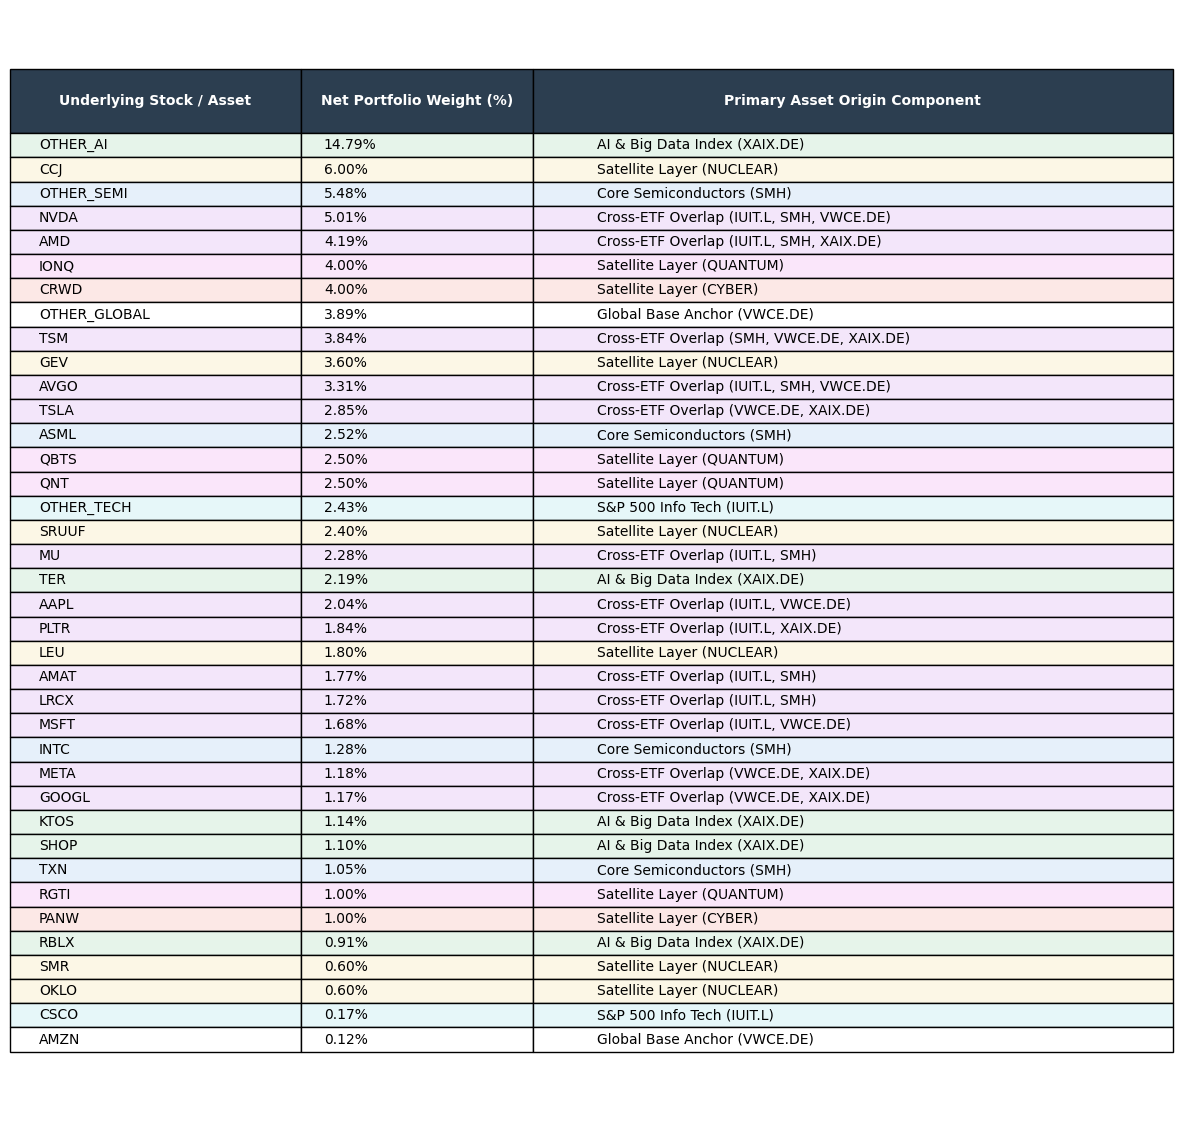

In [ ]:
import pandas as pd

# ANSI Color Codes for terminal printing
RESET = "\033[0m"
BLUE = "\033[34m"          # SMH / Semiconductors
CYAN = "\033[36m"          # IUIT.L / Info Tech
GREEN = "\033[32m"         # XAIX.DE / AI & Big Data
WHITE = "\033[37m"         # VWCE.DE / Global Core
DARKYELLOW = "\033[33m"    # Nuclear Satellite
MAGENTA = "\033[35m"       # Quantum Satellite
RED = "\033[31m"           # Cyber Satellite
PURPLE_BG = "\033[1;35m"   # Cross-ETF Overlaps (Multi)

# =========================================================================
# CONFIGURATION: YOUR TARGET PORTFOLIO WEIGHTS
# =========================================================================
TARGET_WEIGHTS = {
    "VWCE.DE":           0.05,  # 5% Core Global Safety Anchor
    "XAIX.DE":           0.30,  # 30% Core AI & Big Data Index
    "SMH":               0.25,  # 25% Core Semiconductors
    "IUIT.L":            0.10,  # 10% iShares S&P 500 Info Tech
    "NUCLEAR_SATELLITE": 0.15,  # 15% Single Stock Nuclear Basket
    "QUANTUM_SATELLITE": 0.10,  # 10% Single Stock Quantum Basket
    "CYBER_SATELLITE":   0.05   # 5% Single Stock Cybersecurity Basket
}

NUCLEAR_BASKET_TARGETS = {"CCJ": 0.40, "GEV": 0.24, "SRUUF": 0.16, "LEU": 0.12, "SMR": 0.04, "OKLO": 0.04}
QUANTUM_BASKET_TARGETS = {"IONQ": 0.40, "QNT": 0.25, "QBTS": 0.25, "RGTI": 0.10}
CYBER_BASKET_TARGETS   = {"CRWD": 0.80, "PANW": 0.20}

# Exact datasheet tracking data updated for 2026
ETF_LOOK_THROUGH = {
    "SMH": {
        "TSM": 0.1009, "ASML": 0.1008, "NVDA": 0.0992, "AVGO": 0.0959, "MU": 0.0829,
        "AMD": 0.0801, "AMAT": 0.0647, "LRCX": 0.0629, "INTC": 0.0513, "TXN": 0.0422,
        "OTHER_SEMI": 0.2191
    },
    "IUIT.L": {
        "NVDA": 0.2301, "AAPL": 0.1853, "MSFT": 0.1536, "AVGO": 0.0820, "MU": 0.0212,
        "PLTR": 0.0187, "AMD": 0.0185, "CSCO": 0.0171, "AMAT": 0.0152, "LRCX": 0.0149,
        "OTHER_TECH": 0.2434
    },
    "XAIX.DE": {
        "TSLA": 0.0934, "TER": 0.0730, "AMD": 0.0669, "PLTR": 0.0552, "TSM": 0.0412,
        "KTOS": 0.0380, "META": 0.0370, "SHOP": 0.0367, "GOOGL": 0.0353, "RBLX": 0.0304,
        "OTHER_AI": 0.4929
    },
    "VWCE.DE": {
        "NVDA": 0.0458, "AAPL": 0.0383, "MSFT": 0.0297, "AMZN": 0.0249, "GOOGL": 0.0219,
        "AVGO": 0.0189, "TSM": 0.0161, "META": 0.0131, "TSLA": 0.0106,
        "OTHER_GLOBAL": 0.7777
    }
}

# =========================================================================
# MATRIX GENERATION DATA PROCESSING
# =========================================================================
exposure_ledger = []

for etf, micro_allocations in ETF_LOOK_THROUGH.items():
    macro_weight = TARGET_WEIGHTS[etf]
    for stock, sub_weight in micro_allocations.items():
        exposure_ledger.append({
            "Stock/Asset": stock,
            "Net Weight": macro_weight * sub_weight,
            "Source Component": etf
        })

for stock, sub_weight in NUCLEAR_BASKET_TARGETS.items():
    exposure_ledger.append({
        "Stock/Asset": stock,
        "Net Weight": TARGET_WEIGHTS["NUCLEAR_SATELLITE"] * sub_weight,
        "Source Component": "NUCLEAR"
    })

for stock, sub_weight in QUANTUM_BASKET_TARGETS.items():
    exposure_ledger.append({
        "Stock/Asset": stock,
        "Net Weight": TARGET_WEIGHTS["QUANTUM_SATELLITE"] * sub_weight,
        "Source Component": "QUANTUM"
    })

for stock, sub_weight in CYBER_BASKET_TARGETS.items():
    exposure_ledger.append({
        "Stock/Asset": stock,
        "Net Weight": TARGET_WEIGHTS["CYBER_SATELLITE"] * sub_weight,
        "Source Component": "CYBER"
    })

df = pd.DataFrame(exposure_ledger)
summary_df = df.groupby("Stock/Asset").agg({
    "Net Weight": "sum",
    "Source Component": lambda x: list(set(x))
}).reset_index()

summary_df = summary_df.sort_values(by="Net Weight", ascending=False).reset_index(drop=True)

# =========================================================================
# GRAPHICAL MATPLOTLIB TABLE BUILDER
# =========================================================================
fig, ax_table = plt.subplots(figsize=(12, len(summary_df) * 0.35 + 1))
ax_table.axis('off')

# Map rows out to clean text strings
table_data = []
row_colors = []

# HEX Palette choices based on your specifications
HEX_BLUE = "#E6F0FA"        # SMH (Soft Blue)
HEX_CYAN = "#E6F7F9"        # IUIT.L (Soft Cyan)
HEX_GREEN = "#E6F4EA"       # XAIX.DE (Soft Green)
HEX_WHITE = "#FFFFFF"       # VWCE.DE (Clean White)
HEX_DKYELLOW = "#FCF7E6"    # NUCLEAR (Soft Muted Dark Yellow)
HEX_MAGENTA = "#FAE6FA"     # QUANTUM (Soft Light Magenta)
HEX_RED = "#FCE8E6"         # CYBER (Soft Light Red)
HEX_PURPLE = "#F3E6FA"      # MULTI-ETF Overlaps

for _, row in summary_df.iterrows():
    sources = row["Source Component"]
    asset = row["Stock/Asset"]
    weight_str = f"{row['Net Weight'] * 100:.2f}%"

    if len(sources) > 1:
        source_label = f"Cross-ETF Overlap ({', '.join(sorted(sources))})"
        cell_color = HEX_PURPLE
    else:
        src = sources[0]
        if src == "SMH":
            source_label = "Core Semiconductors (SMH)"
            cell_color = HEX_BLUE
        elif src == "IUIT.L":
            source_label = "S&P 500 Info Tech (IUIT.L)"
            cell_color = HEX_CYAN
        elif src == "XAIX.DE":
            source_label = "AI & Big Data Index (XAIX.DE)"
            cell_color = HEX_GREEN
        elif src == "VWCE.DE":
            source_label = "Global Base Anchor (VWCE.DE)"
            cell_color = HEX_WHITE
        elif src == "NUCLEAR":
            source_label = "Satellite Layer (NUCLEAR)"
            cell_color = HEX_DKYELLOW
        elif src == "QUANTUM":
            source_label = "Satellite Layer (QUANTUM)"
            cell_color = HEX_MAGENTA
        elif src == "CYBER":
            source_label = "Satellite Layer (CYBER)"
            cell_color = HEX_RED

    table_data.append([asset, weight_str, source_label])
    # Duplicate color for each column cell in this specific row
    row_colors.append([cell_color, cell_color, cell_color])

# Matplotlib implementation matching your exact layout settings
columns = ["Underlying Stock / Asset", "Net Portfolio Weight (%)", "Primary Asset Origin Component"]
display_table = ax_table.table(
    cellText=table_data,
    colLabels=columns,
    loc='center',
    cellLoc='left',
    colWidths=[0.25, 0.20, 0.55],
    cellColours=row_colors
)

# Style Header Cells to look crisp
for j in range(len(columns)):
    cell = display_table[0, j]
    cell.set_facecolor('#2C3E50')
    cell.get_text().set_color('white')
    cell.get_text().set_weight('bold')
    cell.set_height(0.04)

display_table.auto_set_font_size(False)
display_table.set_fontsize(10)
display_table.scale(1.25, 1.45)

plt.show()

In [ ]:
# =========================================================================
# TACTICAL CRYPTO ASSET DEPLOYMENT ENGINE (CHF DENOMINATED)
# =========================================================================

def get_live_fx_rate(from_curr, to_curr):
    """Fetches real-time exchange rate using yfinance."""
    fx_ticker = f"{from_curr}{to_curr}=X"
    try:
        # Fetching data directly
        data = yf.Ticker(fx_ticker).history(period="1d")
        if not data.empty:
            return float(data['Close'].iloc[-1])
        return 0.89
    except Exception as e:
        print(f"⚠️ FX Auto-fetch failed: {e}")
        return 0.89  # Fallback rate

USD_TO_CHF = get_live_fx_rate("USD", "CHF")

MONTHLY_DEPOSIT_CHF = 1000.0

CRYPTO_TARGET_WEIGHTS = {
    "BTC-USD": 0.40,
    "ETH-USD": 0.25,
    "SOL-USD": 0.15,
    "RENDER-USD": 0.05,
    "LINK-USD": 0.05,
    "XRP-USD": 0.00,
    # "CHSB-USD": 0.00
}

my_current_crypto = {
    "BTC-USD": 0.15,
    "ETH-USD": 4.43,
    "SOL-USD": 74.0,
    # "CHSB-USD": 10000.0,
    "RENDER-USD": 713.0,
    "LINK-USD": 144.96,
    "XRP-USD": 871.0
}

crypto_prices_usd = {}
print("\n🌐 Syncing Crypto Chain Prices...")

# 2. Fetch Prices in USD
for ticker in CRYPTO_TARGET_WEIGHTS.keys():
    try:
        ticker_obj = yf.Ticker(ticker)
        data = ticker_obj.history(period="1d")
        if not data.empty:
            crypto_prices_usd[ticker] = float(data['Close'].iloc[-1])
        else:
            crypto_prices_usd[ticker] = 0.01
    except Exception as e:
        print(f"❌ Error fetching {ticker}: {e}")
        crypto_prices_usd[ticker] = 0.01

# 3. Calculate values
crypto_values_usd = {c: my_current_crypto.get(c, 0) * crypto_prices_usd.get(c, 0) for c in CRYPTO_TARGET_WEIGHTS.keys()}
total_crypto_value_usd = sum(crypto_values_usd.values())

# 4. Identify Drift
chosen_crypto_buy = None
max_crypto_drift = -999.0

for crypto_asset, target_pct in CRYPTO_TARGET_WEIGHTS.items():
    # Avoid division by zero
    c_pct = crypto_values_usd[crypto_asset] / total_crypto_value_usd if total_crypto_value_usd > 0 else 0
    c_drift = target_pct - c_pct
    if c_drift > max_crypto_drift:
        max_crypto_drift = c_drift
        chosen_crypto_buy = crypto_asset

# 5. Output
if chosen_crypto_buy:
    price_usd = crypto_prices_usd[chosen_crypto_buy]
    price_chf = price_usd * USD_TO_CHF
    units_to_buy = MONTHLY_DEPOSIT_CHF / price_chf

    print("\n" + "="*60)
    print(f"🟪 CRYPTO ACTION (CHF Denominated): Buy '{chosen_crypto_buy}'")
    print(f"   Exchange Rate Used: 1 USD = {USD_TO_CHF:.4f} CHF")
    print(f"   Execution Price: {price_chf:.2f} CHF per unit")
    print(f"   Target Purchase Volume: {units_to_buy:.4f} tokens")
    print(f"   Total Investment: {MONTHLY_DEPOSIT_CHF:.2f} CHF")
    print("="*60)


🌐 Syncing Crypto Chain Prices...

🟪 CRYPTO ACTION (CHF Denominated): Buy 'BTC-USD'
   Exchange Rate Used: 1 USD = 0.7881 CHF
   Execution Price: 57357.72 CHF per unit
   Target Purchase Volume: 0.0174 tokens
   Total Investment: 1000.00 CHF


In [ ]:
TODO: Try to understand IPO dates why 06-02
TODO: Circuit Breaker for your Buy Engine (Price drops >50% FORBIDEN TO BUY)
TODO: generate HTML
TODO push on github
TODO: plot crypto like etf
TODO: refine crypto invest
TODO: adapt etf invest (maybe 45% xtrackers is too much?)